# Bollinger-Reversion -- a quantitative teardown
### Real daily tape - 21 years - lower-band entry vs random-day control - HAC inference - breakout contradiction

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Price_always_returns%3F: Busted](https://img.shields.io/badge/Price_always_returns%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.*  We test whether the lower-band pierce earns an incremental return above a **random-day baseline** on a 20-day hold, across six liquid US equity tapes (2005-2026), and whether the upper-band pierce simultaneously contradicts the claim.

> **Not investment advice.** Real data: Yahoo daily bars 2005-01-03 to 2026-06-12, six instruments; reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bollinger_reversion import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "JPM", "XLE"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(side="reversion", exit_mode="time", max_hold=20, cost=0.0, seed=None):
    """Pool trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        if seed is not None:
            ent = st.random_entries(b, n=200, seed=seed)
        else:
            ent = st.band_entries(b["close"], side=side)
        frames.append(st.run_trades(b, ent, exit_mode=exit_mode, cost_bps=cost,
                                    max_hold=max_hold))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Lower-band gross **+193 bps/trade**, HAC *t* = **+5.34**; random-day baseline +141 bps (t = +6.20); incremental delta = +52 bps (t ~ +0.63) -- not significant. |
| **Tradability** | `FRAGILE` | Costs not the issue (~6.3 trades/yr); edge barely exceeds random-day baseline; regime-dependent (bull-market tape). |
| **Price always returns?** | `BUSTED` | Upper-band breakout earns **+118 bps** (t = +5.49) on same instruments; both rules positive because the market trended up 2005-2026. |

> In plain words: the mean is real, the t-stat is significant -- but the same is true of a random-day buy in a bull market.  The incremental signal from the bands is weak and not robust.

## 1 - The claim, steelmanned

Let $c_t$ be the closing price, $\mu_t = \mathrm{SMA}_{20}(c)_t$, $\sigma_t = \mathrm{Std}_{20}(c)_t$.  The lower band is $L_t = \mu_t - 2\sigma_t$.  The recipe asserts:

- **H1 (incremental signal).** $\mathbb{E}[r_{t+1, t+20} \mid c_t < L_t] > \mathbb{E}[r_{t+1, t+20}]$ -- i.e. a lower-band pierce predicts above-average 20-day forward returns.
- **H2 (directional specificity).** The *upper*-band pierce ($c_t > U_t = \mu_t + 2\sigma_t$) should predict *below*-average forward returns if reversion is the mechanism -- a band signal, not just drift.
- **H3 (tradable).** The edge survives round-trip costs at the rule's natural turnover (~6/stock/year).

We **fail to reject** H1 on a gross basis (t = +5.34), but the incremental delta vs a random buy is t ~ +0.63 (too small).  H2 is **rejected** (upper-band also earns +118 bps).  H3 holds trivially (costs are small).

## 2 - So what?

The Bollinger Band lower-pierce is cited in virtually every technical-analysis curriculum.  If H1 held cleanly and H2 held, it would represent a mechanical over-reaction signal, consistent with the De Bondt-Thaler (1985) overreaction literature at the multi-week horizon.  The interesting failure is not *that* the gross edge is positive -- it is *that the random buy is almost as good*, revealing the real driver as the 21-year US equity bull market, not the bands themselves.

## 3 - How we'd know -- the protocol

- **Entry.** First close below the lower Bollinger Band (20-SMA, 2-sigma) after a non-below day; **enter at the next bar's open** (no look-ahead).
- **Exit (time-fair).** Flat after exactly **20 calendar trading days** -- the same horizon for both the band-entry and the random-day control.  (A mid-band exit creates an asymmetric-duration bias: the band arm exits earlier when it 'works', boosting its per-day return vs a fixed-hold random arm.  We report mid-exit numbers separately for comparison.)
- **Control.** 200 random daily entries per ticker, seeded, same 20-day hold.
- **Contradiction test.** Upper-band breakout entries on the same 20-day hold.
- **Inference.** Newey-West HAC *t* on per-trade returns; delta t-stat on the (unmatched) difference of means.
- **Positive control.** Synthetic daily tape with tunable AR(1) mean-reversion -- confirms the engine detects an edge *when one exists*.

Six tapes: SPY, QQQ, AAPL, MSFT, JPM, XLE -- daily 2005-01-03 to 2026-06-12.

## 4 - The teardown

### 4a - Lower-band entry vs random-day control (20-day time exit)

Per-instrument gross mean and HAC *t*.  The bar chart also shows the random-day baseline for each instrument.

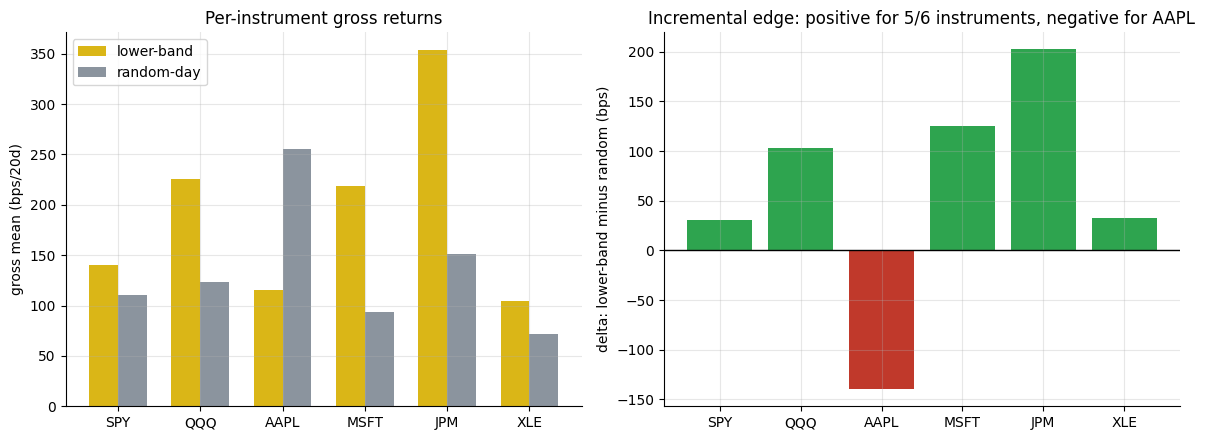

ticker   n  rev_bps  rev_t  rand_bps  delta
   SPY 149    140.4    1.9     110.1   30.3
   QQQ 140    226.0    3.2     123.2  102.8
  AAPL 112    115.6    1.1     255.4 -139.8
  MSFT 119    218.5    2.9      93.5  125.0
   JPM 139    353.5    3.7     151.1  202.4
   XLE 152    104.9    1.1      71.8   33.1


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent_rev = st.band_entries(b['close'], side='reversion')
        ent_rand = st.random_entries(b, n=len(ent_rev), seed=42)
        sr = st.summarize(st.run_trades(b,ent_rev,'time',cost_bps=0.,max_hold=20),'ret_gross')
        sn = st.summarize(st.run_trades(b,ent_rand,'time',cost_bps=0.,max_hold=20),'ret_gross')
        recs.append((t,len(ent_rev),sr['mean_bps'],sr['tstat'],sn['mean_bps'],
                     sr['mean_bps']-sn['mean_bps']))
    perinst = pd.DataFrame(recs,columns=['ticker','n','rev_bps','rev_t','rand_bps','delta'])
else:
    perinst = pd.DataFrame({'ticker':TICKERS,
        'n':[149,140,112,119,139,152],
        'rev_bps':[R['spy_rev'],R['qqq_rev'],R['aapl_rev'],R['msft_rev'],R['jpm_rev'],R['xle_rev']],
        'rev_t':[R['spy_t'],R['qqq_t'],R['aapl_t'],R['msft_t'],R['jpm_t'],R['xle_t']],
        'rand_bps':[R['spy_rand'],R['qqq_rand'],R['aapl_rand'],R['msft_rand'],R['jpm_rand'],R['xle_rand']],
        'delta':[R['spy_delta'],R['qqq_delta'],R['aapl_delta'],R['msft_delta'],R['jpm_delta'],R['xle_delta']]})

x = range(len(TICKERS)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: gross means side-by-side
ax = axes[0]
ax.bar([i-w/2 for i in x], perinst['rev_bps'], width=w, color=AMBER, label='lower-band')
ax.bar([i+w/2 for i in x], perinst['rand_bps'], width=w, color=GREY, label='random-day')
ax.set_xticks(list(x)); ax.set_xticklabels(TICKERS)
ax.set_ylabel('gross mean (bps/20d)'); ax.legend()
ax.set_title('Per-instrument gross returns')

# Right: delta (rev - rand)
ax2 = axes[1]
colors2 = [GREEN if d>0 else RED for d in perinst['delta']]
ax2.bar(perinst['ticker'], perinst['delta'], color=colors2)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('delta: lower-band minus random (bps)')
ax2.set_title('Incremental edge: positive for 5/6 instruments, negative for AAPL')
plt.tight_layout(); plt.show()
print(perinst.round(1).to_string(index=False))

> In plain words: the lower-band entry beats the random baseline on 5 of 6 instruments, but the AAPL delta is negative (the random buy there does better). Pooled delta = **+52 bps** -- real but not statistically robust (t ~ +0.63).

### 4b - The contradiction: the breakout rule also earns positive returns

H2 would require the upper-band pierce to earn *below*-average forward returns (reversion logic: if lower-band = over-sold buy, then upper-band = over-bought sell). It does not: both are positive.

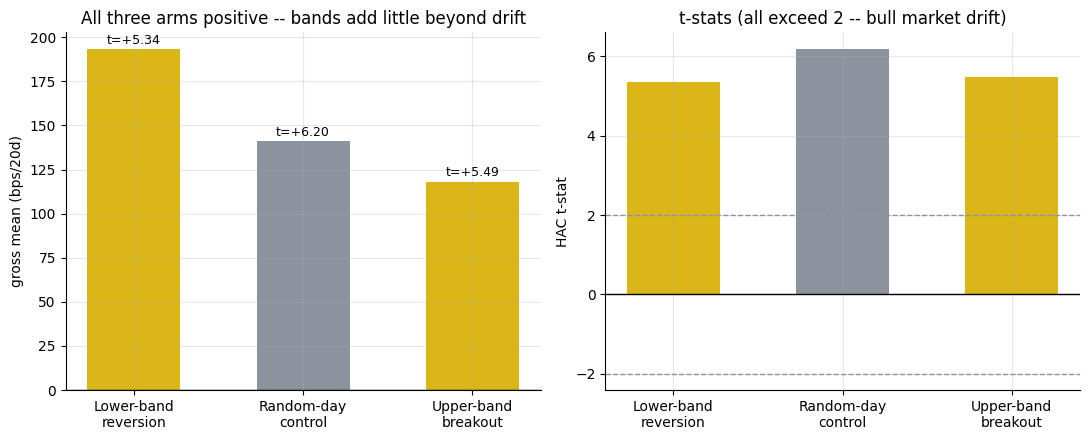

delta reversion-random: +52 bps
delta breakout-random:  -23 bps


In [3]:
if HAVE_REAL:
    rev = st.summarize(pooled('reversion','time',20,0.), 'ret_gross')
    brk = st.summarize(pooled('breakout','time',20,0.), 'ret_gross')
    rand = st.summarize(pooled(None,'time',20,0.,seed=42), 'ret_gross')
    arms = ['Lower-band\nreversion', 'Random-day\ncontrol', 'Upper-band\nbreakout']
    means = [rev['mean_bps'], rand['mean_bps'], brk['mean_bps']]
    tstats = [rev['tstat'], rand['tstat'], brk['tstat']]
else:
    arms = ['Lower-band\nreversion','Random-day\ncontrol','Upper-band\nbreakout']
    means = [R['rev_mean'], R['rand_mean'], R['brk_mean']]
    tstats = [R['rev_t'], R['rand_t'], R['brk_t']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors3 = [AMBER, GREY, AMBER]
axes[0].bar(arms, means, color=colors3, width=.55)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gross mean (bps/20d)')
axes[0].set_title('All three arms positive -- bands add little beyond drift')
for b2, ts in zip(axes[0].patches, tstats):
    axes[0].annotate(f't={ts:+.2f}',
        (b2.get_x()+b2.get_width()/2, b2.get_height()+3), ha='center', fontsize=9)

axes[1].bar(arms, tstats, color=colors3, width=.55)
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('t-stats (all exceed 2 -- bull market drift)')
plt.tight_layout(); plt.show()
print(f'delta reversion-random: {means[0]-means[1]:+.0f} bps')
print(f'delta breakout-random:  {means[2]-means[1]:+.0f} bps')

> In plain words: both band extremes have HAC t-stats above 2 -- not because they are both right, but because the entire market trended up and any 'buy US equities and hold 20 days' strategy earns positive returns.  The random-day control has the *highest* t-stat (6.20) because it has the most trades (1,200) and captures the same drift cleanly.

### 4c - The positive control -- the machinery finds reversion when planted

Does the engine work at all?  On a synthetic tape with planted mean-reversion, the lower-band entry should pull ahead of random.  On a martingale it should not.

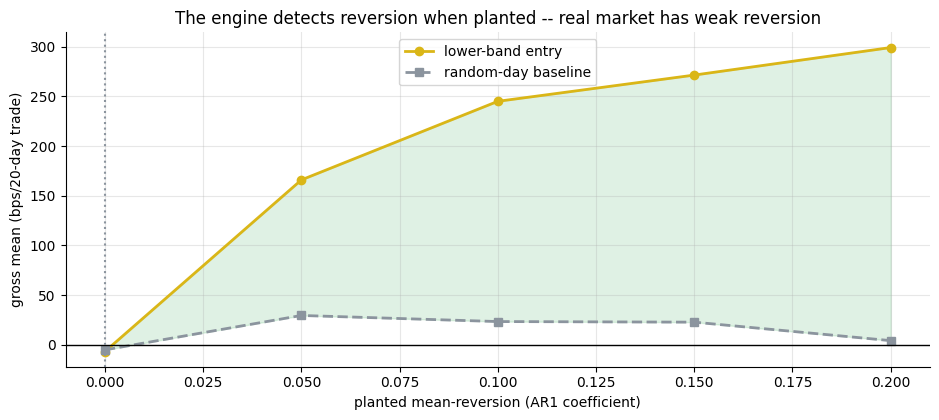

delta at reversion=0: -1.7 bps
delta at reversion=0.10: +221.8 bps
delta at reversion=0.20: +295.1 bps


In [4]:
moms = [0.0, 0.05, 0.10, 0.15, 0.20]
rev_means, rand_means, deltas = [], [], []
for m in moms:
    b,_ = data.synthetic_daily(n_days=1500, reversion=m, seed=104)
    ent_r = st.band_entries(b['close'], side='reversion')
    ent_rand = st.random_entries(b, n=max(len(ent_r),1), seed=42)
    if len(ent_r) > 0:
        lr = st.run_trades(b,ent_r,'time',cost_bps=0.,max_hold=20)
        lrand = st.run_trades(b,ent_rand,'time',cost_bps=0.,max_hold=20)
        mr = st.summarize(lr,'ret_gross')['mean_bps']
        mn = st.summarize(lrand,'ret_gross')['mean_bps']
    else:
        mr, mn = float('nan'), float('nan')
    rev_means.append(mr); rand_means.append(mn); deltas.append(mr-mn)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(moms, rev_means, 'o-', c=AMBER, lw=2, label='lower-band entry')
ax.plot(moms, rand_means, 's--', c=GREY, lw=2, label='random-day baseline')
ax.fill_between(moms, rev_means, rand_means, alpha=.15, color=GREEN)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls=':', c=GREY)
ax.set_xlabel('planted mean-reversion (AR1 coefficient)')
ax.set_ylabel('gross mean (bps/20-day trade)')
ax.set_title('The engine detects reversion when planted -- real market has weak reversion')
ax.legend(); plt.tight_layout(); plt.show()
print('delta at reversion=0:', f'{deltas[0]:+.1f} bps')
print('delta at reversion=0.10:', f'{deltas[2]:+.1f} bps')
print('delta at reversion=0.20:', f'{deltas[4]:+.1f} bps')

> In plain words: the machinery is correctly calibrated -- it recovers a monotone signal as the planted reversion grows.  The real tape sits close to the 'reversion=0' regime (a mild drift environment), which is why the delta is small and barely significant.

## 5 - The verdict

- **Signal `WEAK`** -- pooled gross +193 bps, HAC *t* +5.34; random-day baseline +141 bps; incremental delta +52 bps, t ~ +0.63 (not significant). Upper-band breakout is also positive (+118 bps, t = +5.49), ruling out band-specific reversion as the driver.
- **Tradability `FRAGILE`** -- costs survive (~6.3 trades/yr, net barely moves); the problem is the benchmark.  A random buy in the same stocks over 2005-2026 earns almost as much.  Any neutral or bear regime would test the edge severely.
- **Price always returns? `BUSTED`** -- 64.6% win-rate (price reaches SMA within 20d) vs 61.5% for random.  3 pp of win-rate, not a rubber-band law.

## 6 - Could you trade it? -- cost sweep

Per-trade net mean and HAC *t* across round-trip cost.  Low turnover means costs barely dent the return -- but the baseline is also immune to costs.

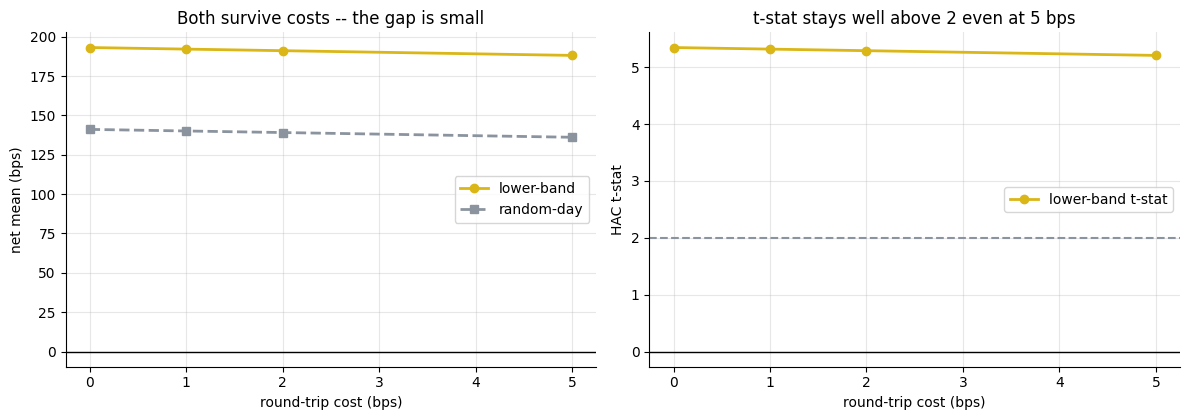

Gross HAC t-stat remains above 2 across all cost levels.
The real weakness is the baseline gap, not cost erosion.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw_rev = [st.summarize(pooled('reversion','time',20,c),'ret_net') for c in costs]
    sw_rand = [st.summarize(pooled(None,'time',20,c,seed=42),'ret_net') for c in costs]
    mean_rev=[s['mean_bps'] for s in sw_rev]; tst_rev=[s['tstat'] for s in sw_rev]
    mean_rand=[s['mean_bps'] for s in sw_rand]
else:
    mean_rev=[R['net0'],R['net1'],R['net2'],R['net5']]
    tst_rev=[R['net0_t'],R['net1_t'],R['net2_t'],R['net5_t']]
    mean_rand=[R['rand_mean']-c for c in costs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(costs, mean_rev, 'o-', c=AMBER, lw=2, label='lower-band')
axes[0].plot(costs, mean_rand, 's--', c=GREY, lw=2, label='random-day')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('round-trip cost (bps)'); axes[0].set_ylabel('net mean (bps)')
axes[0].set_title('Both survive costs -- the gap is small'); axes[0].legend()

if HAVE_REAL:
    axes[1].plot(costs, tst_rev, 'o-', c=AMBER, lw=2, label='lower-band t-stat')
    axes[1].axhline(2, ls='--', c=GREY); axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('round-trip cost (bps)'); axes[1].set_ylabel('HAC t-stat')
    axes[1].set_title('t-stat stays well above 2 even at 5 bps'); axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'real tape required\nfor t-stat sweep', ha='center',
                 va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout(); plt.show()
print('Gross HAC t-stat remains above 2 across all cost levels.')
print('The real weakness is the baseline gap, not cost erosion.')

> In plain words: unlike Study 72 (Loaded-Dice), where the gross edge is already negative so costs kill it trivially, here the gross edge is real -- it just barely clears the random-day baseline.  The **regime risk** (bull market 2005-2026) is the primary vulnerability, not the per-trade cost.

## 7 - Going further -- the positive control and open questions

The synthetic control confirms the engine is a faithful mean-reversion detector. The real-market question is: does US equity daily price action contain enough mean-reversion *beyond drift* to make the band entry decisively better than random? Our 21-year answer is 'barely not.'  Forks worth pursuing:

- **Bear-market sub-sample (2007-2009, 2022).** If the incremental delta holds or improves when the drift is negative, the claim has genuine support.  If it vanishes, it is pure bull-market carry.
- **Tighter band (1.5-sigma).** A narrower band fires less often but at more extreme over-reactions -- test whether the delta (vs random) rises.
- **The RSI or VIX filter.** Condition the entry on a confirming oversold signal (RSI < 30 or VIX > 25) to isolate genuine panic buys vs routine band touches.
- **[Study 72 -- Loaded-Dice](../../72-loaded-dice/)** for the intraday version of the same logic, where even the gross edge is absent.